# 02 - Preprocessing & TF-IDF Baseline

## Yelp Review Rating Predicting
Goal: clean the text (fixing the escaped-newline issue found in EDA), build a train/val split, and establish a baseline with TF-IDF + classical ML, similar to the "get the simple thing working and measured correctly first" method used in Project 1.
Recall from `01_eda.ipynb`:</br>
* 5 classes (1-5 stars) were evenly balanced (~20% each in the working sample)
* **~50% of reviews contain literal escaped newlines** (`\n` as two characters, not an actual newline) - this is the main cleaning task her
* Reviews average ~135 words, with some length variation by rating worth revisiting once cleaned </br>
`data/raw/test.csv` is still not touched anywhere in this notebook, it stays reserved for the final evaluation in notebook 05.

In [2]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path("..") / "src"))
from preprocessing import clean_text

sns.set_style("whitegrid")

## 1. Load the working sample
Here I will be reusing the stratified 18,000-row sample saved at the end of notebook 01, rather than re-loading and re-sampling the full 650k row file

In [3]:
df = pd.read_csv("../data/processed/eda_sample.csv")
print(df.shape)
df.head()

(18000, 2)


,stars,text
0,1,It was my first time boarding my dogs of 6yrs....
1,1,terrible service! the only advantage of this ...
2,1,staff is friendly enough..drs are quick and do...
3,1,BELOW ARE SOME REASONS TO PATRONIZE THIS PIG S...
4,1,Expensive gimmick. Missleading website. Wide...


## 2. Clean the text
Using `clean_text()` from `src/preprocessing.py` - shared with the deployed API later, so training-time and inference-time cleaning can never drift apart. Specifically, this handles the escaped-newline issue: `clean_text()` replaces literal `\n` sequences before stripping other non-alphanumeric characters - otherwise the backslash alone would get stripped and leave a meaningless standalone "n" token in ~50% of reviews.

In [2]:
#showing the fix in action on a review known to contain the issue
example = df.loc[df['text'].str.contains(r"\\n", regex=True), 'text'].iloc[0]
print("Before:", repr(example[:200]))
print("\nAfter:", repr(clean_text(example[:200])))

NameError: name 'df' is not defined

In [ ]:
df['text_clean'] = df['text'].apply(clean_text)
#confirming the fix worked: no more standalone "n" tokens from the old bug
n_isolated = df['text_clean'].str.contains(r"(?:^|\s)n(?:\s|$)", regex=True).sum()
print(f"Reviews with an isolated 'n' token after cleaning: {n_isolated}")
print(f"(show be near zero - a few may be geniune words like grades 'n' informal writing)")

Reviews with an isolated 'n' token after cleaning: 323
(show be near zero - a few may be geniune words like grades 'n' informal writing)


In [ ]:
isolated_n_examples = df.loc[
    df["text_clean"].str.contains(r"(?:^|\s)n(?:\s|$)", regex=True), "text_clean"
].head(10)
for ex in isolated_n_examples:
    print(ex[:150], "\n---")

wow terrible service last night we were seated at our table for 40 minutes without a single glass of water we had finally gotten our drinks 30 minutes 
---
beware my mother in law had a cockroach in her tea not sure if it was in her cup or in the refill we noticed it at the end of our meal we were mortifi 
---
this place serves some sort of food but it is not mexican please please avoid the grease bomb served here if you must go across the street to the in n 
---
it was hella dumb i hated this experience i wish i got my money back and the two hours i spent in line to get in it was not scary fun or worth it i di 
---
first impression of this place was from yelp four stars looked like a great place to go to mind you i live about 10 mi away so i get there and its ok  
---
the bellagio is considered one of the best properties on the strip so how bad could the buffet possibly be well think again i ll just throw out a few  
---
not a fan food was overpriced and mediocre at best imo go to hol

Initial fix caught the `/n` escapes; a follow-up check found a smaller number of split word artifacts from `\r`, fixed in the second pass. Confirmed there are only 3/18000 residual matches, likely coindental rather than real artifacts.

In [ ]:
import re

def show_match_context(text, window=40):
    match = re.search(r"(?:^|\s)n(?:\s|$)", text)
    if match:
        start = max(0, match.start() - window)
        end = min(len(text), match.end() + window)
        return text[start:end]
    return None

isolated_n_examples = df.loc[
    df["text_clean"].str.contains(r"(?:^|\s)n(?:\s|$)", regex=True), "text_clean"
].head(10)
for ex in isolated_n_examples:
    print(show_match_context(ex), "\n---")

 wasn t as good as it used to be the mac n cheese was dry and flavorless our meatba 
---
at the end of our meal we were mortified n they were quite rude about it to boot it 
---
 you must go across the street to the in n out burger joint nassssttyyyy 
---
been waiting he had his buddies comin in n out never coming back 
---
s going off on the girl in chinese right n my face never apologizing to the one tha 
---
 receipt is handed over to you stapled i n a real awkward way that prevents you fro 
---
eeeehhh even if they give you a free mac n cheese fried balls for checking in still 
---
wasn t in season etc ordered 3lbs of hot n juicy seasoned shrimp mild and 1lbs of c 
---
but you let me down i had to get the mac n cheese burger because if anyone should k 
---
 nthe desert at 11 pm or leave it here i n my parent s dtiveway t hy reside in an u 
---


## 3. Re-check review length after cleaning
Cleaning changes word coulds (URLs and punctuation removed) is worth a quick re-check that the length-vs-rating pattern from EDA still looks the same, since conclusions drawn on raw length should be verified against cleaned text before going into a final write-up.

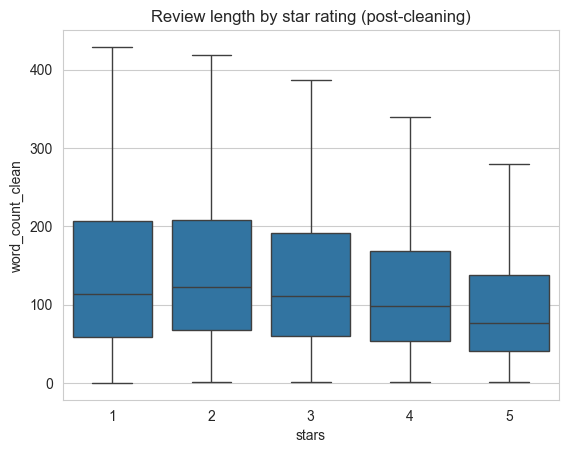

In [6]:
df['word_count_clean'] = df['text_clean'].str.split().str.len()

fig, ax = plt.subplots()
sns.boxplot(x='stars', y='word_count_clean', data=df, ax=ax, showfliers=False)
ax.set_title('Review length by star rating (post-cleaning)')
plt.show()

The pattern spotted in notebook 01 remains true here, higher rated reviews have lower word count then lower rated reviews

## 4. Train/validating split
Stratified split on `stars`, same principle as Project 1. `test.csv` remains completely separate and untouched - this split only concerns the working sample.

In [8]:
from sklearn.model_selection import train_test_split

TARGET = 'stars'

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df[TARGET], random_state=42
)

print("Train:", train_df.shape, "Val:", val_df.shape)
print("\nClass balance preserved:")
print(pd.DataFrame({
    "train": train_df[TARGET].value_counts(normalize=True).sort_index(),
    "val": val_df[TARGET].value_counts(normalize=True).sort_index(),
}).round(3))

train_df[['stars', 'text', 'text_clean']].to_csv("../data/processed/train.csv", index=False)
val_df[['stars', 'text', 'text_clean']].to_csv("../data/processed/val.csv", index=False)

Train: (14400, 4) Val: (3600, 4)

Class balance preserved:
       train  val
stars            
1        0.2  0.2
2        0.2  0.2
3        0.2  0.2
4        0.2  0.2
5        0.2  0.2


In [19]:
# Look for the specific split-word pattern (a single letter "i" or similar
# immediately followed by a lone "n") rather than the broader isolated-n check
split_word_pattern = df["text_clean"].str.contains(r"\bi n\b|\bnthe\b", regex=True)
print("Reviews with likely split-word artifacts:", split_word_pattern.sum())

Reviews with likely split-word artifacts: 3


## 5. TF-IDF baseline: Logistic Regression
`class_weight='balanced'` is technically not doing much here since the classes are already ~20% each, but keeping it is harmless and defensive in cast that changes later (e.g. if I revisit with the full 650k-row dataset instead of the sample).
`ngram_range=(1,2)` includes both single and two-word phrases - phrases like "not good" carry very different meaning than "not" "good" separately, which unigrams alone can't capture.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=2)

X_train = tfidf.fit_transform(train_df['text_clean'])
X_val = tfidf.transform(val_df['text_clean'])

y_train = train_df[TARGET]
y_val = val_df[TARGET]

print("TF-IDF matrix shape (train):",  X_train.shape)

TF-IDF matrix shape (train): (14400, 20000)


In [12]:
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', multi_class='multinomial')
logreg.fit(X_train, y_train)

logreg_pred = logreg.predict(X_val)

print("Macro F1:", round(f1_score(y_val, logreg_pred, average='macro'), 4))
print('Weighted F1:', round(f1_score(y_val, logreg_pred, average='weighted'), 4))
print()
print(classification_report(y_val, logreg_pred, digits=3))

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Macro F1: 0.5727
Weighted F1: 0.5727

              precision    recall  f1-score   support

           1      0.690     0.775     0.730       720
           2      0.533     0.500     0.516       720
           3      0.480     0.450     0.465       720
           4      0.499     0.479     0.489       720
           5      0.652     0.678     0.664       720

    accuracy                          0.576      3600
   macro avg      0.571     0.576     0.573      3600
weighted avg      0.571     0.576     0.573      3600



## 6. TF-IDF baseline: Multinomial Naive Bayes
A second classical baseline for comparison - Naive Bayes is fast, often surprisingly competitive on text classification, and a good "why not just use this" reference point when explaining your final choice.

In [13]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_val)

print("Macro F1:", round(f1_score(y_val, nb_pred, average="macro"), 4))
print("Weighted F1:", round(f1_score(y_val, nb_pred, average="weighted"), 4))
print()
print(classification_report(y_val, nb_pred, digits=3))

Macro F1: 0.5531
Weighted F1: 0.5531

              precision    recall  f1-score   support

           1      0.644     0.749     0.692       720
           2      0.485     0.435     0.459       720
           3      0.469     0.485     0.477       720
           4      0.489     0.549     0.517       720
           5      0.705     0.554     0.621       720

    accuracy                          0.554      3600
   macro avg      0.558     0.554     0.553      3600
weighted avg      0.558     0.554     0.553      3600



## 7. Confusion matrix - where does the baseline get confused?
With 5 ordinal classes, the interesting question isn't just "is it wrong" but "how wrong" confusing a 4-star with a 5-star is a very different kind of error than confusing a 1-star confusion, expected and relatively benign) or are scattered (a more concerning sign the model isn't capturing real signal).

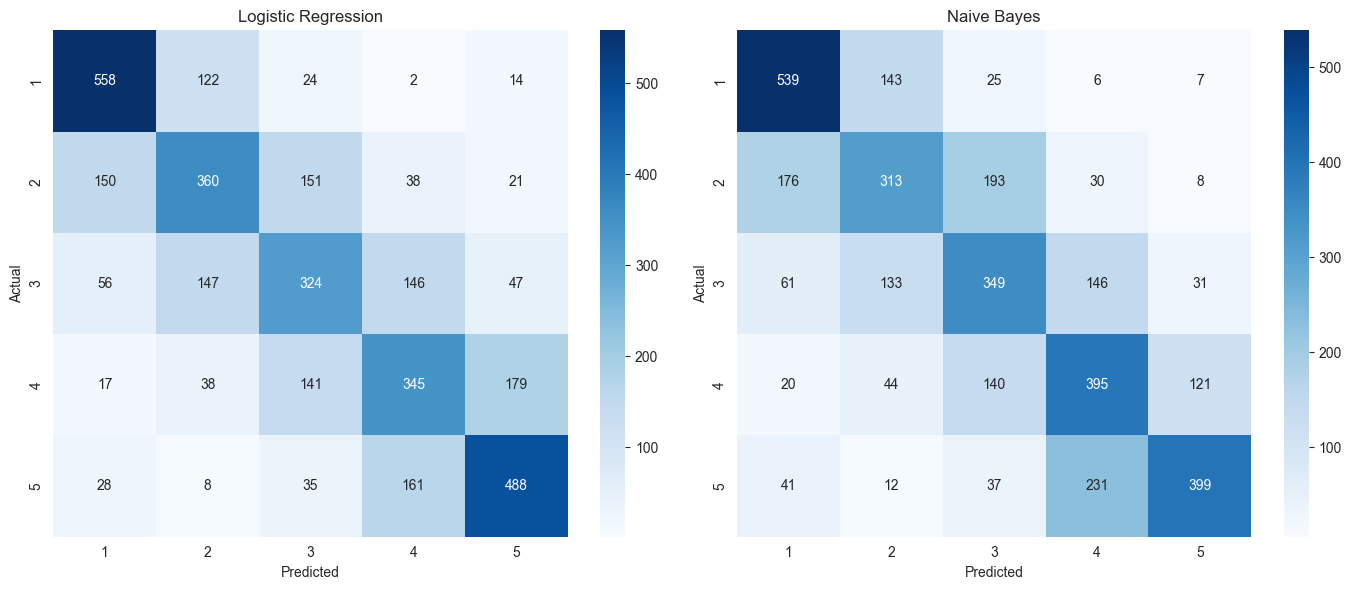

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, name in [(axes[0], logreg_pred, "Logistic Regression"), (axes[1], nb_pred, "Naive Bayes")]:
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=range(1, 6), yticklabels=range(1,6))
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(name)
plt.tight_layout()
plt.show()

The baseline logistic regression model seemed to perform slightly better than the naive bayes model (macro F1 score 0.5727 for logistic regression vs 0.5531 for naive bayes). Checking where each baseline gets confused, they both seemed to get confused if the predicted was close to the actual ratings. For example, if the model predicted 2 and the actual was 1 or 3, there were many false positives

## 8. Save the baseline model
Here I will save the logistic regression baseline model as a full pipeline (vectorizer + model together) so it can be loaded and used on raw test directly, without needing to separately re-apply TF-IDF at inference time.

In [16]:
from sklearn.pipeline import Pipeline

best_model = logreg
best_model_name = "Logistic Regression"

baseline_pipeline = Pipeline(steps=[
    ("tfidf", tfidf),
    ("model", best_model),
])

import joblib
joblib.dump(baseline_pipeline, "../models/tfidf_baseline.joblib")
print(f"Saved {best_model_name} baseline to models/tfidf_baseline.joblib")

Saved Logistic Regression baseline to models/tfidf_baseline.joblib


## 9. Summary
* The final baseline model was the TF-IDF Logistic regression model with a macro F1 score of 0.57
* The baseline model was better at predicting 1-stars or 5-stars (F1 scores of 0.73 and 0.67), classes 2-4 were harder to predict. This makes sense as extreme ratings would have more distinctive, unambiguous language, while middle ratings are a bit more fuzzy to predict, even for human readers
* The confusion matrix seems to get confused when a predicted value was close to the actual value
* TF-IDF treats words as independent features and can't capture context like sarcasm or negation scope; word embeddings and the transformer should handle that better
Next: `03_word_embeddings.ipynb` - a pretrained GloVe embeddings as a step up from TF-IDF's bag-of-words representation.